<a href="https://colab.research.google.com/github/Aria05MC/PlayGround/blob/main/AIImageGenerator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Instalation Python

# Pin numpy to <2.4 to satisfy numba dependency requirements
!pip install --upgrade scipy "numpy<2.4"

!pip -q install \
    torch \
    torchvision \
    torchaudio \
    diffusers \
    transformers \
    accelerate \
    safetensors \
    sentencepiece \
    "rembg[gpu]"



# **Machine Setup**

In [1]:
#@title Instalasi Cloudflare

!pip -q install fastapi uvicorn python-multipart pillow

!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
-O cloudflared

!chmod +x cloudflared

!./cloudflared --version

cloudflared version 2026.7.3 (built 2026-07-23-09:58 UTC)


In [2]:
import torch
from diffusers import DiffusionPipeline

# MODEL_ID = "votepurchase/waiNSFWIllustrious_v140"
MODEL_ID = "frankjoshua/waiIllustriousSDXL_v170"

pipe = DiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    use_safetensors=True,
)

pipe.enable_attention_slicing()
pipe.enable_vae_slicing()
pipe.enable_model_cpu_offload()

print("Model Loaded!")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Model Loaded!


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2273: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


In [ ]:
%%writefile index.html
<!DOCTYPE html>
<html>
<head>
<title>WAI Illustrious Ultimate</title>
<script src="https://cdn.tailwindcss.com"></script>
<style>
    .slider-label { display: flex; justify-content: space-between; font-size: 0.75rem; color: #a1a1aa; text-transform: uppercase; margin-bottom: 0.25rem; }
    .loading-pulse { animation: pulse 2s cubic-bezier(0.4, 0, 0.6, 1) infinite; }
    @keyframes pulse { 0%, 100% { opacity: 1; } 50% { opacity: .5; } }
</style>
</head>
<body class="bg-gradient-to-br from-zinc-950 via-purple-950 to-black min-h-screen text-white flex items-center justify-center p-4">
    <div class="w-full max-w-6xl bg-zinc-900/80 backdrop-blur rounded-3xl shadow-2xl p-8">
        <div class="flex justify-between items-center mb-6">
            <div>
                <h1 class="text-4xl font-bold text-transparent bg-clip-text bg-gradient-to-r from-purple-400 to-pink-600">🎨 WAI Illustrious Pro</h1>
                <p class="text-zinc-400 text-sm">High-Performance Web Generator</p>
            </div>
            <div id="status-badge" class="px-3 py-1 rounded-full text-xs font-bold bg-zinc-800 text-zinc-500">READY</div>
        </div>

        <form id="form" class="grid grid-cols-1 lg:grid-cols-4 gap-6">
            <div class="lg:col-span-2 space-y-4">
                <div>
                    <label class="block mb-2 font-medium text-purple-400">Positive Prompt</label>
                    <textarea name="prompt" class="w-full h-40 rounded-xl bg-zinc-800 border border-zinc-700 p-4 text-white focus:ring-2 focus:ring-purple-500">masterpiece, best quality, </textarea>
                </div>
                <div>
                    <label class="block mb-2 font-medium text-red-400">Negative Prompt</label>
                    <textarea name="negative_prompt" class="w-full h-24 rounded-xl bg-zinc-800 border border-zinc-700 p-4 text-white focus:ring-2 focus:ring-red-500">low quality, worst quality, blurry, bad anatomy, extra fingers</textarea>
                </div>
            </div>

            <div class="lg:col-span-2 grid grid-cols-1 md:grid-cols-2 gap-4 bg-zinc-800/50 p-6 rounded-2xl border border-zinc-700">
                <div class="space-y-4">
                    <div>
                        <div class="slider-label"><span>Width</span><span id="w_val">768</span></div>
                        <input type="range" name="width" min="256" max="1280" step="64" value="768" class="w-full accent-purple-500" oninput="document.getElementById('w_val').innerText=this.value">
                    </div>
                    <div>
                        <div class="slider-label"><span>Height</span><span id="h_val">1024</span></div>
                        <input type="range" name="height" min="256" max="1280" step="64" value="1024" class="w-full accent-purple-500" oninput="document.getElementById('h_val').innerText=this.value">
                    </div>
                    <div>
                        <div class="slider-label"><span>Guidance</span><span id="gs_val">7.0</span></div>
                        <input type="range" name="guidance_scale" min="1" max="20" step="0.5" value="7.0" class="w-full accent-purple-500" oninput="document.getElementById('gs_val').innerText=this.value">
                    </div>
                </div>

                <div class="space-y-4">
                    <div>
                        <div class="slider-label"><span>Steps</span><span id="steps_val">28</span></div>
                        <input type="range" name="num_inference_steps" min="10" max="50" step="1" value="28" class="w-full accent-purple-500" oninput="document.getElementById('steps_val').innerText=this.value">
                    </div>
                    <div>
                        <div class="slider-label"><span>Batch Count</span><span id="batch_val">1</span></div>
                        <input type="range" name="num_images" min="1" max="4" step="1" value="1" class="w-full accent-purple-500" oninput="document.getElementById('batch_val').innerText=this.value">
                    </div>
                    <div class="flex items-center justify-between p-2 bg-zinc-700/50 rounded-lg">
                        <span class="text-xs uppercase text-zinc-400">Remove BG</span>
                        <input type="checkbox" name="remove_bg" class="w-5 h-5 accent-purple-500">
                    </div>
                </div>

                <button id="button" class="md:col-span-2 w-full bg-purple-600 hover:bg-purple-700 rounded-xl py-4 font-bold text-lg transition shadow-lg shadow-purple-900/20">🚀 Generate Now</button>
            </div>
        </form>

        <div id="loading" class="hidden mt-8 text-center">
            <div class="loading-pulse inline-block w-8 h-8 border-4 border-purple-500 border-t-transparent rounded-full mb-2"></div>
            <p id="loading-text" class="text-purple-300">Connecting to AI engine...</p>
        </div>

        <div id="result-container" class="mt-8 grid grid-cols-1 md:grid-cols-2 lg:grid-cols-3 gap-4"></div>
    </div>

    <script>
        document.getElementById("form").addEventListener("submit", async(e) => {
            e.preventDefault();
            const btn = document.getElementById("button");
            const load = document.getElementById("loading");
            const loadText = document.getElementById("loading-text");
            const status = document.getElementById("status-badge");
            const container = document.getElementById("result-container");

            btn.disabled = true;
            load.classList.remove("hidden");
            loadText.innerText = "Processing diffusion steps...";
            status.innerText = "BUSY";
            status.className = "px-3 py-1 rounded-full text-xs font-bold bg-purple-900/50 text-purple-400";
            container.innerHTML = "";

            try {
                const data = new FormData(e.target);
                const response = await fetch("/generate", { method: "POST", body: data });
                const result = await response.json();

                result.images.forEach(imgData => {
                    const div = document.createElement('div');
                    div.className = "relative group";
                    const img = document.createElement('img');
                    img.src = `data:image/png;base64,${imgData}`;
                    img.className = "rounded-2xl shadow-xl w-full border-2 border-zinc-800 hover:border-purple-500 transition-all cursor-pointer";
                    img.onclick = () => window.open(img.src);
                    div.appendChild(img);
                    container.appendChild(div);
                });
                status.innerText = "SUCCESS";
                status.className = "px-3 py-1 rounded-full text-xs font-bold bg-green-900/50 text-green-400";
            } catch (err) {
                alert("Generation failed. Check Colab logs.");
                status.innerText = "ERROR";
                status.className = "px-3 py-1 rounded-full text-xs font-bold bg-red-900/50 text-red-400";
            }

            load.classList.add("hidden");
            btn.disabled = false;
            setTimeout(() => {
                status.innerText = "READY";
                status.className = "px-3 py-1 rounded-full text-xs font-bold bg-zinc-800 text-zinc-500";
            }, 5000);
        });
    </script>
</body>
</html>

# **The Program**

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (112 > 77). Running this sequence through the model will result in indexing errors
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CLIPTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['ring gag . she is in nightclub , the ambient is cool , warm , little dark with lights , with camera angle from front little to the right from top head to buttom feet .']
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (

  0%|          | 0/28 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


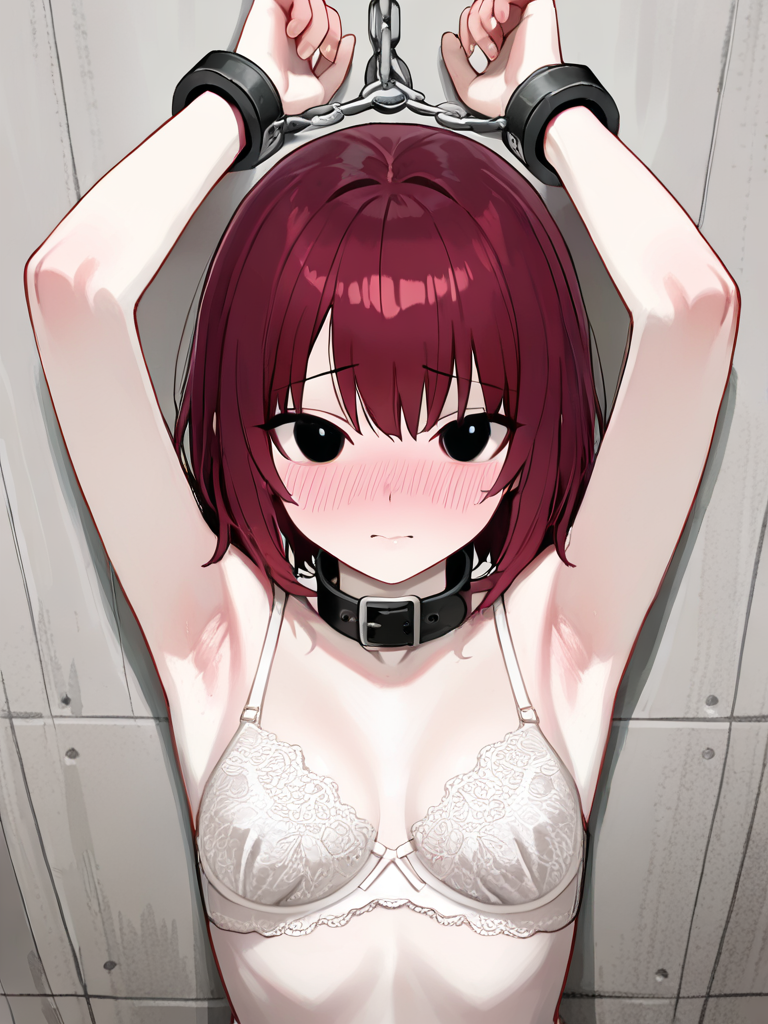

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
#@title 🎨 Image Generation Settings

prompt = "She has dark red hair, beige skin, black eyes, a soft jawline, and simple cat lips. Her face is blush in shyness, feel humilinated. Her hands were cuffed and attach to her dog collar behind her neck, making her hands rise, exposing her armpit. She only wear white lacy bra with lacy panties. Her mouth is cover with ring gag. She is in nightclub, the ambient is cool, warm, little dark with lights, with camera angle from front little to the right from top head to buttom feet." #@param {type:"string"}

negative = "low quality, worst quality, blurry, bad anatomy, extra fingers" #@param {type:"string"}

width = 768 #@param {type:"integer"}
height = 1024 #@param {type:"integer"}

guidance_scale = 7.0 #@param {type:"number"}
num_inference_steps = 28 #@param {type:"integer"}

num_images = 1 #@param {type:"slider", min:1, max:10, step:1}
remove_background = "no" #@param ["no", "yes"]
#@title 🚀 Generate

from IPython.display import display
from google.colab import files
if remove_background == "yes":
    from rembg import remove

import gc
import torch

with torch.inference_mode():
    images = pipe(
        prompt=prompt,
        negative_prompt=negative,
        width=width,
        height=height,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps,
        num_images_per_prompt=1
    ).images


for i, image in enumerate(images, start=1):

    if remove_background == "yes":
        image = remove(image.convert("RGBA"))
    image.save(f"result_{i}.png")

    display(image)


#@title 📥 Download Options

download = "y" #@param ["y", "n"]


if download.lower() == "y":
    if len(images) == 1:
        files.download("result_1.png")
    else:
        import zipfile

        zip_name = "generated_images.zip"

        with zipfile.ZipFile(zip_name, "w") as z:
            for i in range(1, len(images)+1):
                z.write(f"result_{i}.png")

        files.download(zip_name)

del images
gc.collect()
torch.cuda.empty_cache()